# Notebook 02 — Расчёт метрик

**Цель:** вычислить расширенный набор метрик по каждой акции.

## Изменения vs предыдущей версии

| Группа | Убрано | Добавлено |
|---|---|---|
| Риск | VaR 95% (ρ=0.96 с σ) | CVaR 95%, Downside deviation |
| Доходность | mean_return, cum_return (ρ>0.94 с Sharpe) | Information ratio, Win rate |
| Динамика | — | Approximate entropy, Variance ratio |
| Межрыночные | — | corr_calm, corr_stress, Tail dependence, R² |

**Итого: 23 метрики** (было 16)

In [13]:
pip install antropy arch

Note: you may need to restart the kernel to use updated packages.


In [14]:
import warnings, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

prices         = pd.read_parquet('data/prices.parquet')
log_returns    = pd.read_parquet('data/log_returns.parquet')
simple_returns = pd.read_parquet('data/simple_returns.parquet')
sp500_ret      = pd.read_parquet('data/sp500_index.parquet')['sp500']

TICKERS   = prices.columns.tolist()
RISK_FREE = 0.04 / 252

# Рыночные режимы
sp500_vol     = sp500_ret.rolling(21).std() * np.sqrt(252)
VOL_THRESHOLD = float(sp500_vol.median())
CALM_DATES    = sp500_vol[sp500_vol <= VOL_THRESHOLD].index
STRESS_DATES  = sp500_vol[sp500_vol >  VOL_THRESHOLD].index

print(f"Акций: {len(TICKERS)} | Дней: {len(prices)}")
print(f"Период: {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"Волатильность (медиана): {VOL_THRESHOLD:.3f}")
print(f"Спокойных: {len(CALM_DATES)} | Стрессовых: {len(STRESS_DATES)}")

Акций: 481 | Дней: 1509
Период: 2019-01-02 → 2024-12-30
Волатильность (медиана): 0.137
Спокойных: 744 | Стрессовых: 744


## Группа 1 — Риск

In [15]:
def calc_sigma(r):
    return float(r.std() * np.sqrt(252))

def calc_beta(r, mkt):
    a = pd.concat([r, mkt], axis=1).dropna()
    if len(a) < 100: return np.nan
    c = np.cov(a.values.T)
    return float(c[0,1] / c[1,1])

def calc_max_drawdown(price):
    cum = price / price.iloc[0]
    return float((cum - cum.cummax()).div(cum.cummax()).min())

def calc_cvar95(r):
    """
    CVaR (Expected Shortfall) 95%.
    Среднее по наихудшим 5% дней — строже VaR,
    учитывает размер потерь за порогом. Стандарт Basel III.
    """
    thr  = np.percentile(r.dropna(), 5)
    tail = r[r <= thr]
    return float(tail.mean()) if len(tail) > 0 else np.nan

def calc_downside_dev(r, rf):
    """
    Downside Deviation — σ только ниже безрисковой ставки.
    Различает «плохую» и «хорошую» волатильность.
    Основа коэффициента Сортино.
    """
    neg = (r - rf)[r < rf]
    if len(neg) < 10: return np.nan
    return float(np.sqrt((neg**2).mean()) * np.sqrt(252))

print("✓ Группа 1 (Риск)")

✓ Группа 1 (Риск)


## Группа 2 — Доходность

In [16]:
def calc_sharpe(r, rf):
    excess = r - rf
    s = excess.std()
    return float(excess.mean() / s * np.sqrt(252)) if s > 1e-10 else np.nan

def calc_info_ratio(r, mkt):
    """
    Information Ratio = (R_i - R_m) / Tracking Error.
    Sharpe vs бенчмарк (S&P 500), а не безрисковая ставка.
    IR > 0.5 — хорошо в активном управлении.
    """
    a = pd.concat([r, mkt], axis=1).dropna()
    if len(a) < 100: return np.nan
    active = a.iloc[:,0] - a.iloc[:,1]
    te = active.std()
    return float(active.mean() / te * np.sqrt(252)) if te > 1e-10 else np.nan

def calc_momentum(price, days):
    if len(price) <= days: return np.nan
    return float(price.iloc[-1] / price.iloc[-days-1] - 1)

def calc_win_rate(r):
    """
    Доля дней с положительной доходностью.
    Дополняет Шарп: высокий win_rate при низком Шарпе =
    маленькие частые прибыли и редкие крупные потери.
    """
    return float((r.dropna() > 0).mean())

print("✓ Группа 2 (Доходность)")

✓ Группа 2 (Доходность)


## Группа 4 — Межрыночные связи

In [17]:
def calc_corr(r, mkt):
    a = pd.concat([r, mkt], axis=1).dropna()
    if len(a) < 100: return np.nan
    return float(a.iloc[:,0].corr(a.iloc[:,1]))

def calc_corr_regime(r, mkt, regime_dates):
    """
    Корреляция в конкретном режиме рынка.
    corr_stress - corr_calm = correlation breakdown:
    насколько вырастает корреляция в стресс.
    """
    dates = r.index.intersection(mkt.index).intersection(regime_dates)
    if len(dates) < 30: return np.nan
    return float(r.loc[dates].corr(mkt.loc[dates]))

def calc_tail_dependence(r, mkt, q=0.05):
    """
    Lower tail dependence.
    P(акция падает | рынок падает) в нижних q%.
    Низкое → истинный диверсификатор в кризис.
    """
    a = pd.concat([r, mkt], axis=1).dropna()
    if len(a) < 100: return np.nan
    rv, mv  = a.iloc[:,0], a.iloc[:,1]
    m_low   = mv <= mv.quantile(q)
    if m_low.sum() == 0: return np.nan
    return float(((rv <= rv.quantile(q)) & m_low).sum() / m_low.sum())

def calc_r_squared(r, mkt):
    """
    R² = ρ². Доля дисперсии объяснённая рынком.
    β=1.5 при R²=0.3 → бета ненадёжна.
    """
    c = calc_corr(r, mkt)
    return float(c**2) if not np.isnan(c) else np.nan

print("✓ Группа 4 (Межрыночные)")

✓ Группа 4 (Межрыночные)


## Основной цикл расчёта

**~15–25 минут** для 500 акций.
Approximate Entropy — самая медленная (~1–2 сек/акция).

In [18]:
records, errors = [], []
t0 = time.time()

for ticker in tqdm(TICKERS, desc='Расчёт метрик'):
    try:
        s = simple_returns[ticker].dropna()
        l = log_returns[ticker].dropna()
        p = prices[ticker].dropna()

        if len(s) < 500:
            errors.append((ticker, 'insufficient_data'))
            continue

        mkt = sp500_ret.reindex(s.index).dropna()
        s_a = s.reindex(mkt.index)

        rec = {'ticker': ticker}

        # Группа 1
        rec['sigma']        = calc_sigma(s)
        rec['beta']         = calc_beta(s_a, mkt)
        rec['max_dd']       = calc_max_drawdown(p)
        rec['cvar_95']      = calc_cvar95(s)
        rec['downside_dev'] = calc_downside_dev(s, RISK_FREE)

        # Группа 2
        rec['sharpe']     = calc_sharpe(s, RISK_FREE)
        rec['info_ratio'] = calc_info_ratio(s_a, mkt)
        rec['mom_1m']     = calc_momentum(p, 21)
        rec['mom_12m']    = calc_momentum(p, 252)
        rec['win_rate']   = calc_win_rate(s)

        

        # Группа 4
        rec['corr_sp500']      = calc_corr(s_a, mkt)
        rec['corr_calm']       = calc_corr_regime(s, sp500_ret, CALM_DATES)
        rec['corr_stress']     = calc_corr_regime(s, sp500_ret, STRESS_DATES)
        rec['tail_dependence'] = calc_tail_dependence(s_a, mkt)
        rec['r_squared']       = calc_r_squared(s_a, mkt)

        records.append(rec)

    except Exception as e:
        errors.append((ticker, str(e)))

df_features = pd.DataFrame(records).set_index('ticker')
print(f"\n✓ {(time.time()-t0)/60:.1f} мин | "
      f"Успешно: {len(df_features)} | Ошибки: {len(errors)}")
if errors: print(f"  Примеры: {errors[:5]}")

Расчёт метрик:   0%|          | 0/481 [00:00<?, ?it/s]


✓ 0.1 мин | Успешно: 481 | Ошибки: 0


## Проверка качества

In [19]:
ALL_FEATURES = [
    'sigma','beta','max_dd','cvar_95','downside_dev',
    'sharpe','info_ratio','mom_1m','mom_12m','win_rate',
    
    'corr_sp500','corr_calm','corr_stress',
    'tail_dependence','r_squared',
]

FEATURE_GROUPS = {
    'risk'    : ['sigma','beta','max_dd','cvar_95','downside_dev'],
    'return'  : ['sharpe','info_ratio','mom_1m','mom_12m','win_rate'],
    'dynamics': ['hurst','ac_lag1','ac_lag5','skewness','kurtosis',
                 'freq_ratio','approx_entropy','variance_ratio'],
    'market'  : ['corr_sp500','corr_calm','corr_stress',
                 'tail_dependence','r_squared'],
}

nan_cnt = df_features[ALL_FEATURES].isna().sum()
print("Пропущенные значения:")
print(nan_cnt[nan_cnt>0].to_string() if nan_cnt[nan_cnt>0].any() else "  Нет ✓")

print("\nДиапазоны новых метрик:")
for feat, lo, hi in [
    ('cvar_95',        -0.5, 0.0),
    ('downside_dev',    0.0, 2.0),
    ('win_rate',        0.0, 1.0),
    ('tail_dependence', 0.0, 1.0),
    ('r_squared',       0.0, 1.0),
]:
    col   = df_features[feat].dropna()
    n_bad = ((col<lo)|(col>hi)).sum()
    print(f"  {feat:20s}: {'✓' if n_bad==0 else f'⚠ {n_bad} выбросов'}")

print(f"\nОписательная статистика:")
df_features[ALL_FEATURES].describe().round(4)

Пропущенные значения:
  Нет ✓

Диапазоны новых метрик:
  cvar_95             : ✓
  downside_dev        : ✓
  win_rate            : ✓
  tail_dependence     : ✓
  r_squared           : ✓

Описательная статистика:


,sigma,beta,max_dd,cvar_95,downside_dev,sharpe,info_ratio,mom_1m,mom_12m,win_rate,corr_sp500,corr_calm,corr_stress,tail_dependence,r_squared
count,481.0000,481.0000,481.0000,481.0000,481.0000,481.0000,481.0000,481.0000,481.0000,481.0000,481.0000,481.0000,481.0000,481.0000,481.0000
mean,0.3467,0.9976,-0.5050,-0.0493,0.3482,0.3938,0.0860,-0.0601,0.1786,0.5224,0.5890,0.3883,0.6536,0.4135,0.3590
std,0.0987,0.2967,0.1399,0.0131,0.0918,0.2724,0.3596,0.0689,0.3557,0.0157,0.1099,0.1279,0.1074,0.0954,0.1228
min,0.1932,0.2687,-0.9899,-0.1415,0.1911,-0.5298,-0.9923,-0.3227,-0.6014,0.4749,0.1756,0.0472,0.2038,0.1370,0.0308
25%,0.2806,0.7967,-0.5862,-0.0555,0.2863,0.2157,-0.1720,-0.0979,-0.0322,0.5120,0.5303,0.3045,0.5942,0.3425,0.2812
50%,0.3232,0.9945,-0.4873,-0.0461,0.3266,0.3678,0.0536,-0.0682,0.1342,0.5223,0.5993,0.3988,0.6661,0.4110,0.3592
75%,0.3883,1.1768,-0.4139,-0.0405,0.3881,0.5598,0.2930,-0.0306,0.3326,0.5326,0.6661,0.4790,0.7313,0.4795,0.4438
max,1.1151,2.3586,-0.2257,-0.0278,0.9649,1.3366,1.4465,0.4794,2.8345,0.5684,0.8216,0.6915,0.8661,0.6712,0.6751


## Корреляционная матрица

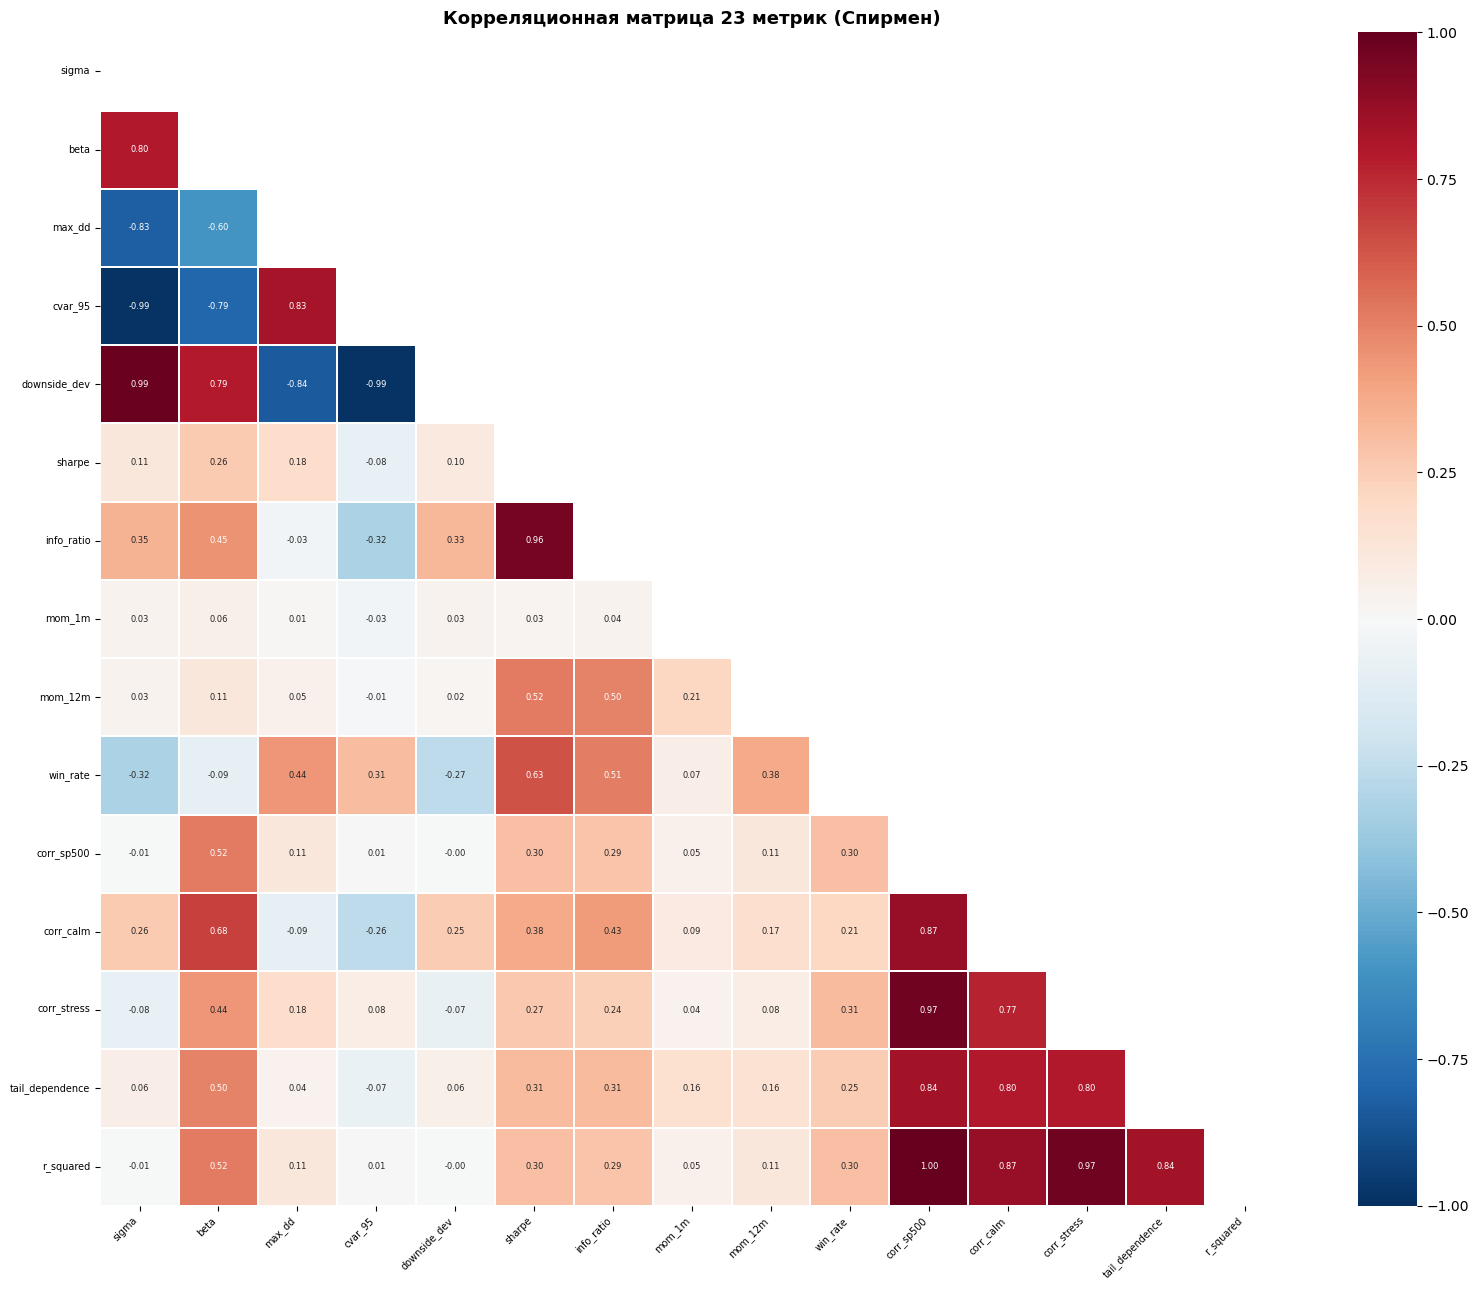

Пары с |ρ| > 0.85:
  sigma                ↔ cvar_95             : -0.986
  sigma                ↔ downside_dev        : 0.986
  cvar_95              ↔ downside_dev        : -0.991
  sharpe               ↔ info_ratio          : 0.960
  corr_sp500           ↔ corr_calm           : 0.868
  corr_sp500           ↔ corr_stress         : 0.971
  corr_sp500           ↔ r_squared           : 1.000
  corr_calm            ↔ r_squared           : 0.868
  corr_stress          ↔ r_squared           : 0.971


In [20]:
corr = df_features[ALL_FEATURES].corr(method='spearman')

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, linewidths=0.3,
    annot_kws={'size': 6}, ax=ax
)
ax.set_title('Корреляционная матрица 23 метрик (Спирмен)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig('plots/02_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Пары с |ρ| > 0.85:")
found = False
for i in range(len(ALL_FEATURES)):
    for j in range(i+1, len(ALL_FEATURES)):
        r = corr.iloc[i,j]
        if abs(r) > 0.85:
            print(f"  {ALL_FEATURES[i]:20s} ↔ {ALL_FEATURES[j]:20s}: {r:.3f}")
            found = True
if not found:
    print("  Нет пар с |ρ| > 0.85 ✓")

## Санитарная проверка

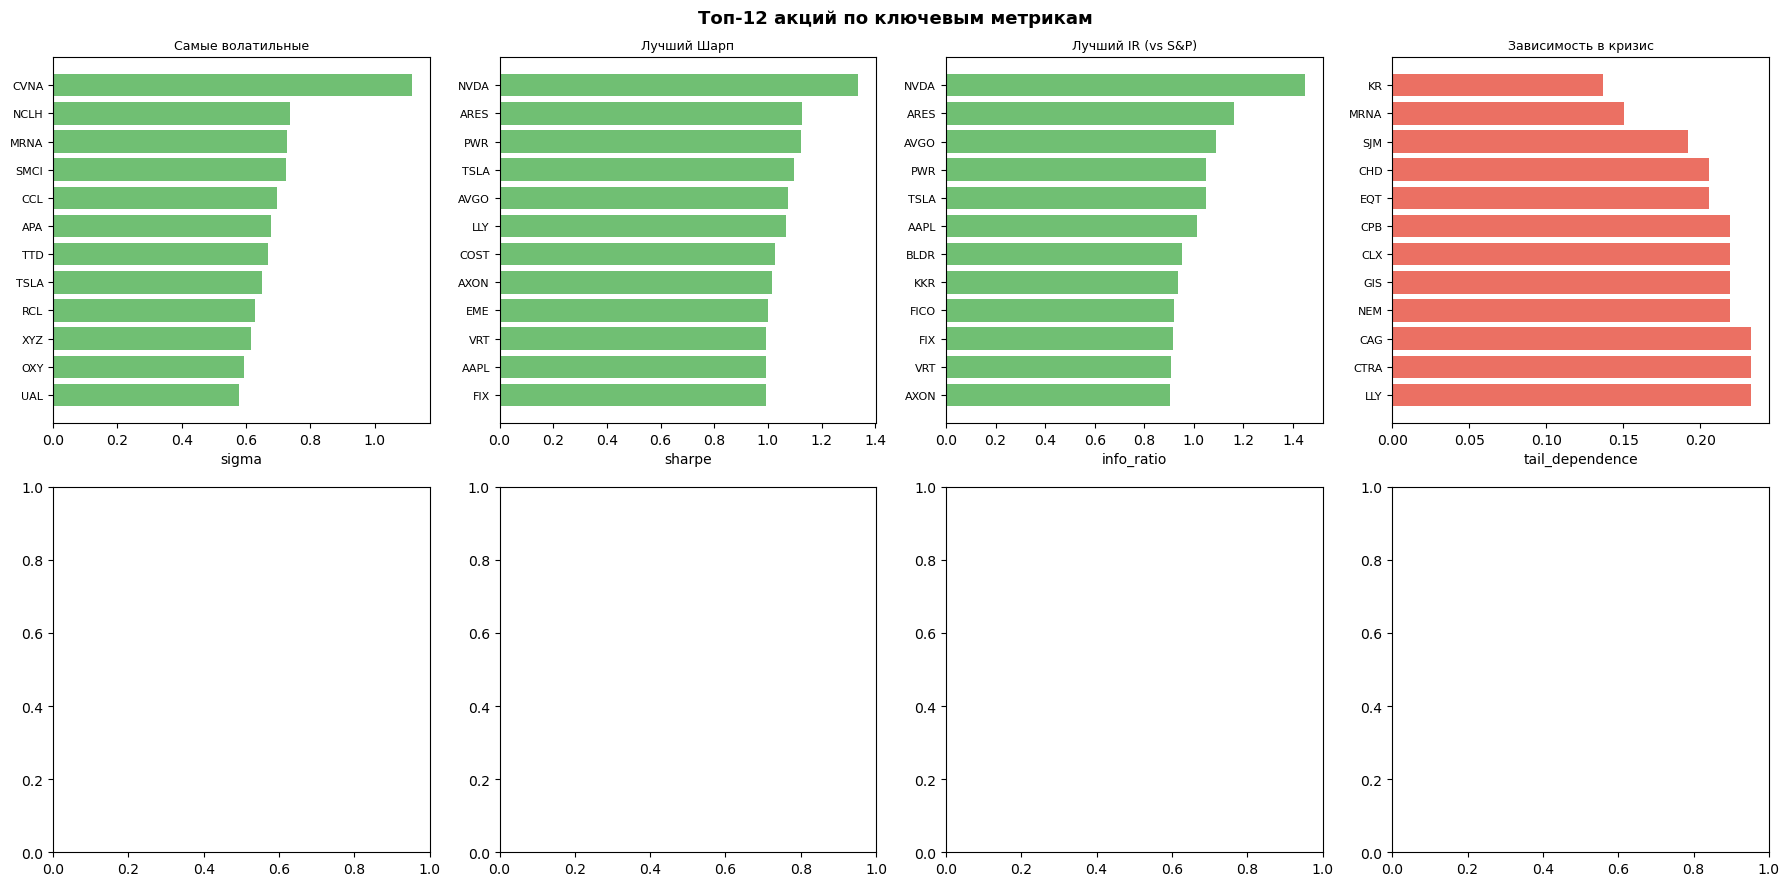

Ключевые наблюдения:
  Info Ratio > 0.5:         62 акций
  Win Rate > 0.55:          17 акций
  Correlation breakdown >0.1: 477 акций
  R² > 0.7 (объяснимы):     0 акций


In [23]:
spot = [
    ('sigma',          True,  'Самые волатильные'),
    ('sharpe',         True,  'Лучший Шарп'),
    ('info_ratio',     True,  'Лучший IR (vs S&P)'),
   
    ('tail_dependence',False, 'Зависимость в кризис'),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Топ-12 акций по ключевым метрикам', fontsize=13, fontweight='bold')
for ax, (feat, largest, title) in zip(axes.flatten(), spot):
    top   = df_features[feat].nlargest(12) if largest else df_features[feat].nsmallest(12)
    color = '#4CAF50' if largest else '#e74c3c'
    ax.barh(top.index[::-1], top.values[::-1], color=color, alpha=0.8)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(feat)
    ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig('plots/02_sanity_check.png', dpi=150, bbox_inches='tight')
plt.show()

print("Ключевые наблюдения:")
print(f"  Info Ratio > 0.5:         {(df_features['info_ratio']>0.5).sum()} акций")
print(f"  Win Rate > 0.55:          {(df_features['win_rate']>0.55).sum()} акций")

cb = (df_features['corr_stress']-df_features['corr_calm']).dropna()
print(f"  Correlation breakdown >0.1: {(cb>0.1).sum()} акций")
print(f"  R² > 0.7 (объяснимы):     {(df_features['r_squared']>0.7).sum()} акций")

## Сохранение

In [26]:
df_features.to_parquet('data/features.parquet')
df_features.round(6).to_csv('data/features.csv')

# Обновлённые группы без дублей
import json
FEATURE_GROUPS_NEW = {
    'risk'    : ['sigma', 'beta', 'max_dd'],
    'return'  : ['sharpe', 'mom_1m','mom_12m', 'win_rate'],
    'dynamics': ['kurtosis', 'skewness', 'variance_ratio',
                 'ac_lag1', 'ac_lag5', 'vol_ratio'],
    'market'  : ['corr_sp500', 'corr_calm', 'tail_dependence'],
}
with open('data/feature_groups.json', 'w') as f:
    json.dump(FEATURE_GROUPS_NEW, f, indent=2)
print("feature_groups.json обновлён")
print(f"Итого метрик: {sum(len(v) for v in FEATURE_GROUPS_NEW.values())}")

print("✓ Сохранено:")
print(f"  data/features.parquet     {df_features.shape}")
print(f"  data/feature_groups.json  4 группы | {len(ALL_FEATURES)} метрик")
print(f"\n{'='*50}")
print(f"  Акций: {len(df_features)} | Метрик: {len(ALL_FEATURES)} (было 16)")
print(f"  Следующий шаг: notebook_01_eda.ipynb")
print(f"{'='*50}")

feature_groups.json обновлён
Итого метрик: 16
✓ Сохранено:
  data/features.parquet     (481, 15)
  data/feature_groups.json  4 группы | 15 метрик

  Акций: 481 | Метрик: 15 (было 16)
  Следующий шаг: notebook_01_eda.ipynb
